## Gráfico creado por Copilot


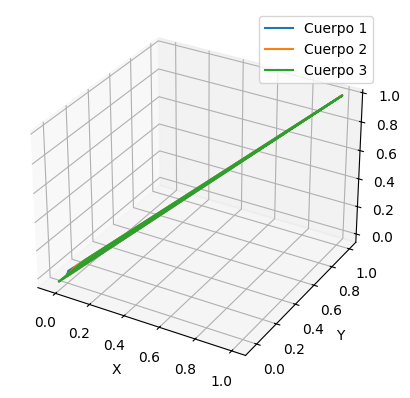

In [49]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pymcel import *  # Asegúrate de importar la clase correcta
from pymcel import ncuerpos_solucion # Asegúrate de importar la función de integración

# 1. Definir los parámetros del sistema (3 cuerpos)
# Ejemplo: Un sistema jerárquico o aleatorio simple
# Masas
m1 = 1.0
m2 = 0.5
m3 = 0.2
masas = np.array([m1, m2, m3])

# Condiciones Iniciales (Posiciones x, y, z)
r1 = [0.0, 0.0, 0.0]
r2 = [1.0, 0.0, 0.0]
r3 = [0.0, 1.0, 0.0]

# Condiciones Iniciales (Velocidades vx, vy, vz)
v1 = [0.0, 0.0, 0.0]
v2 = [0.0, 1.0, 0.0]
v3 = [-0.5, 0.0, 0.1]

# Concatenar en un solo array de estado inicial [x1, y1, z1, ..., vx1, vy1, vz1, ...]
# Dependiendo de cómo pymcel espere la entrada, a veces es [r1, r2, r3, v1, v2, v3] aplanado
condiciones_iniciales = np.concatenate([r1, r2, r3, v1, v2, v3])

# 2. Crear el objeto Vector_Sistema
# Este objeto encapsula el estado y las masas
sistema1 = [
    { "m": 1.0, "r": [0.0, 0.0, 0.0], "v": [0.0, 0.0, 0.0] },
    { "m": 0.5, "r": [1.0, 0.0, 0.0], "v": [0.0, 1.0, 0.0] },
    { "m": 0.2, "r": [0.0, 1.0, 0.0], "v": [-0.5, 0.0, 0.1] }
]
# 3. Definir el tiempo de integración
t_inicial = 0
t_final = 20
paso = 0.01
tiempos = np.arange(t_inicial, t_final, paso)

# 4. Integrar usando ncuerpos_solucion
# Esta función devuelve las posiciones y velocidades en el tiempo
rs1, vs, rps, vps, cuadraturas = ncuerpos_solucion(sistema1, tiempos)

# 5. Visualización básica de las trayectorias (opcional)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extraer coordenadas de la solución
# rs1 suele tener forma (len(tiempos), 3*N)
x1, y1, z1 = rs1[:, 0], rs1[:, 1], rs1[:, 2]
x2, y2, z2 = rs1[:, 3], rs1[:, 4], rs1[:, 5]
x3, y3, z3 = rs1[:, 6], rs1[:, 7], rs1[:, 8]

ax.plot(x1, y1, z1, label='Cuerpo 1')
ax.plot(x2, y2, z2, label='Cuerpo 2')
ax.plot(x3, y3, z3, label='Cuerpo 3')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

## Gráfica 3-dimensional

In [50]:
# Extraer coordenadas de rs (shape: 3, 1000, 3)
x1_p = rs[0, :, 0]
y1_p = rs[0, :, 1]
z1_p = rs[0, :, 2]

x2_p = rs[1, :, 0]
y2_p = rs[1, :, 1]
z2_p = rs[1, :, 2]

x3_p = rs[2, :, 0]
y3_p = rs[2, :, 1]
z3_p = rs[2, :, 2]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x1_p, y=y1_p, z=z1_p,
    mode='lines+markers',
    marker=dict(size=2),
    line=dict(width=2),
    name='Cuerpo 1'
))

fig.add_trace(go.Scatter3d(
    x=x2_p, y=y2_p, z=z2_p,
    mode='lines+markers',
    marker=dict(size=2),
    line=dict(width=2),
    name='Cuerpo 2'
))

fig.add_trace(go.Scatter3d(
    x=x3_p, y=y3_p, z=z3_p,
    mode='lines+markers',
    marker=dict(size=2),
    line=dict(width=2),
    name='Cuerpo 3'
))

# Puntos iniciales
fig.add_trace(go.Scatter3d(
    x=[x1_p[0]], y=[y1_p[0]], z=[z1_p[0]],
    mode='markers',
    marker=dict(size=6, symbol='circle', color='blue'),
    name='Inicio Cuerpo 1'
))
fig.add_trace(go.Scatter3d(
    x=[x2_p[0]], y=[y2_p[0]], z=[z2_p[0]],
    mode='markers',
    marker=dict(size=6, symbol='circle', color='red'),
    name='Inicio Cuerpo 2'
))
fig.add_trace(go.Scatter3d(
    x=[x3_p[0]], y=[y3_p[0]], z=[z3_p[0]],
    mode='markers',
    marker=dict(size=6, symbol='circle', color='green'),
    name='Inicio Cuerpo 3'
))

fig.update_layout(
    title='Trayectorias 3D - Sistema de 3 Cuerpos',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    legend=dict(x=0, y=1)
)

fig.show()

## Animación

In [51]:
# Animación 3D del movimiento de las tres partículas con Plotly

n_steps = len(ta)

frames = []
for k in range(n_steps):
    frames.append(
        go.Frame(
            data=[
                go.Scatter3d(
                    x=[x1_p[k]], y=[y1_p[k]], z=[z1_p[k]],
                    mode='markers',
                    marker=dict(size=6, color='blue'),
                    name='Cuerpo 1'
                ),
                go.Scatter3d(
                    x=[x2_p[k]], y=[y2_p[k]], z=[z2_p[k]],
                    mode='markers',
                    marker=dict(size=6, color='red'),
                    name='Cuerpo 2'
                ),
                go.Scatter3d(
                    x=[x3_p[k]], y=[y3_p[k]], z=[z3_p[k]],
                    mode='markers',
                    marker=dict(size=6, color='green'),
                    name='Cuerpo 3'
                ),
            ],
            traces=[3, 4, 5],  # actualiza solo los marcadores
            name=str(k)
        )
    )

fig_anim = go.Figure(
    data=[
        # Trayectorias completas (líneas fijas)
        go.Scatter3d(
            x=x1_p, y=y1_p, z=z1_p,
            mode='lines',
            line=dict(color='blue', width=2),
            name='Trayectoria 1'
        ),
        go.Scatter3d(
            x=x2_p, y=y2_p, z=z2_p,
            mode='lines',
            line=dict(color='red', width=2),
            name='Trayectoria 2'
        ),
        go.Scatter3d(
            x=x3_p, y=y3_p, z=z3_p,
            mode='lines',
            line=dict(color='green', width=2),
            name='Trayectoria 3'
        ),
        # Marcadores iniciales (primer frame)
        go.Scatter3d(
            x=[x1_p[0]], y=[y1_p[0]], z=[z1_p[0]],
            mode='markers',
            marker=dict(size=6, color='blue'),
            name='Cuerpo 1'
        ),
        go.Scatter3d(
            x=[x2_p[0]], y=[y2_p[0]], z=[z2_p[0]],
            mode='markers',
            marker=dict(size=6, color='red'),
            name='Cuerpo 2'
        ),
        go.Scatter3d(
            x=[x3_p[0]], y=[y3_p[0]], z=[z3_p[0]],
            mode='markers',
            marker=dict(size=6, color='green'),
            name='Cuerpo 3'
        ),
    ],
    layout=go.Layout(
        title='Animación 3D - Sistema de 3 cuerpos',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        updatemenus=[
            dict(
                type='buttons',
                showactive=False,
                buttons=[
                    dict(
                        label='Play',
                        method='animate',
                        args=[
                            None,
                            dict(
                                frame=dict(duration=20, redraw=True),
                                fromcurrent=True,
                                transition=dict(duration=0)
                            )
                        ]
                    ),
                    dict(
                        label='Pause',
                        method='animate',
                        args=[
                            [None],
                            dict(
                                frame=dict(duration=0, redraw=False),
                                mode='immediate',
                                transition=dict(duration=0)
                            )
                        ]
                    )
                ]
            )
        ],
        sliders=[{
            'steps': [
                dict(
                    method='animate',
                    args=[
                        [str(k)],
                        dict(
                            mode='immediate',
                            frame=dict(duration=0, redraw=True),
                            transition=dict(duration=0)
                        )
                    ],
                    label=f'{ta[k]:.2f}'
                ) for k in range(n_steps)
            ],
            'transition': dict(duration=0),
            'x': 0,
            'y': 0,
            'currentvalue': dict(prefix='t = ')
        }]
    ),
    frames=frames
)

fig_anim.show()

## Calculando la energía mecánica

In [ ]:
sistema = [
    dict( m = 1, r = [0, 0, 0], v = [0, 0, 0] ),
    dict( m = 1, r = [-1, 0, 0], v = [0, 1, 0.5] ),
    dict( m = 0.1, r = [1, 0, 0], v = [0, -0.1, 0] )
]

ts = np.linspace(0, 5, 1000)
rs, vs1, rps, vps, cuadraturas = ncuerpos_solucion(sistema, ts)

In [63]:
K = np.sum([0.5 * sistema[i]['m'] * np.linalg.norm(vs1[i, 0, :])**2 for i in range(3)])

K

np.float64(0.6255000000000001)

In [54]:
G = 1 #Unidades canónicas   
U = 0

for i in range(3):
    for j in range(i+1, 3):
            U += - 0.5 * G * sistema[i]['m'] * sistema[j]['m'] / np.linalg.norm(rs[i, 0, :] - rs[j, 0, :])

U

np.float64(-0.5750000000000001)

In [55]:
E = K + U
E

np.float64(0.05049999999999999)

## Cálculo del momento de inercia

In [56]:
I = 0

for i in range(3):

    I += sistema[i]['m'] * np.linalg.norm(rs[i, :, :])**2

In [57]:
I

np.float64(5686.347092180532)

In [66]:
Is = 0
Gs = 0
for i in range(3):

    Is += sistema[i]['m'] * np.linalg.norm(rps[i, :, :], axis = 1)**2
    Gs += sistema[i]['m'] * rps[i, :, :] @ vps[i, :, :]

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1000 is different from 3)